# HealthGuard Insurance — Medical Charges Analysis & Pricing Models

**EECE 6544: Introduction to Machine Learning and Pattern Recognition · Summer 2026 · MiniProject #02**

**Stakeholder:** Ms. Sarah Nabil, Head of Pricing, HealthGuard Insurance

HealthGuard currently prices its plans with outdated actuarial tables — underpricing high-risk customers (losses) and overpricing low-risk ones (churn to competitors). This notebook translates Ms. Nabil's three requirements into machine-learning tasks and delivers them end to end:

| # | Stakeholder requirement (her words) | ML translation | Section |
|---|---|---|---|
| 1 | *"Understand our customers first"* | Exploratory data analysis (≥ 5 visuals + insights) | 3–4 |
| 2 | *"Predict the medical charges"* | Regression — 7 model families, compared on MAE/MSE/RMSE/R² | 5–6 |
| 3 | *"Flag the expensive customers"* | Binary classification — expensive ⇔ charges > median | 7 |

**Dataset:** [Medical Cost Personal Datasets (Kaggle)](https://www.kaggle.com/datasets/mirichoi0218/insurance) — 1,338 customer records: `age`, `sex`, `bmi`, `children`, `smoker`, `region`, `charges` (annual medical cost billed, USD).

**Reproducibility:** the raw dataframe is never mutated (all cleaning happens on a copy), every random operation uses `random_state = 42`, and the cleaned data is written to a separate file (`data/insurance_clean.csv`).

## 1. Setup

Imports, a fixed random seed, and a consistent colorblind-safe chart theme.
One color rule is used everywhere: **blue = non-smoker / neutral series, red = smoker / risk** — color follows the entity on every chart, so the visuals can be read as one system by the board.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             root_mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)

RANDOM_STATE = 42

# --- Chart theme: a validated colorblind-safe palette used consistently throughout ---
BLUE, GREEN, MAGENTA, YELLOW = "#2a78d6", "#008300", "#e87ba4", "#eda100"
AQUA, ORANGE, VIOLET, RED = "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"
CATEGORICAL = [BLUE, GREEN, MAGENTA, YELLOW, AQUA, ORANGE, VIOLET, RED]
SMOKER_COLORS = {"no": BLUE, "yes": RED}          # color follows the entity on every chart
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SURFACE = "#fcfcfb"
DIVERGING = LinearSegmentedColormap.from_list("brand_div", [BLUE, "#f0efec", RED])
SEQ_BLUES = LinearSegmentedColormap.from_list("brand_blues", ["#cde2fb", "#3987e5", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titleweight": "bold", "axes.titlesize": 11.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "figure.dpi": 110,
})

CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

def save_show(fig, name):
    # Save a copy for the report, then display inline
    fig.savefig(CHARTS / name, dpi=150, bbox_inches="tight")
    plt.show()

print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__} | seaborn {sns.__version__}")

pandas 3.0.1 | numpy 2.4.2 | scikit-learn 1.8.0 | seaborn 0.13.2


## 2. Load & profile the data

The file is read with an explicit `encoding="utf-8"`. Profiling uses `head`, `shape`, `info`, `describe`, and `value_counts` to assess size, structure, and quality before touching anything.

In [2]:
df_raw = pd.read_csv("data/insurance.csv", encoding="utf-8")
print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}")
df_raw.head(10)

Rows: 1,338 | Columns: 7


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
# Numeric profile
df_raw.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [5]:
# Categorical profile
df_raw.describe(include=["object", "str"])

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [6]:
for col in ["sex", "smoker", "region", "children"]:
    print(df_raw[col].value_counts(), end="\n\n")
print("Smoker share:")
print(df_raw["smoker"].value_counts(normalize=True).round(3))

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

Smoker share:
smoker
no     0.795
yes    0.205
Name: proportion, dtype: float64


**Profiling observations**

- 1,338 rows × 7 columns; no column is entirely or partially empty (`info()` shows 1,338 non-null everywhere).
- Types look correct: `age`/`children` are integers, `bmi`/`charges` are floats, `sex`/`smoker`/`region` are strings.
- Categories are already tidy (exactly 2 sexes, 2 smoker values, 4 regions — no obvious typos), but we will standardize case/whitespace defensively anyway.
- `charges` spans \$1,122 → \$63,770 with mean ≫ median — a strong right skew we must look at in EDA.
- ~20% of customers smoke; regions and sexes are roughly balanced.

## 3. Data cleaning

**Strategy:** the raw dataframe `df_raw` is treated as immutable — every operation happens on the copy `df`, and the cleaned result is saved to a *separate* file. Each decision is stated with its rationale (summary table at the end of this section).

In [7]:
# Work on a copy - the raw dataframe stays untouched (immutability principle)
df = df_raw.copy()

### 3.1 Missing values

In [8]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing

,missing_count,missing_pct
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


**Decision:** no missing values anywhere, so no imputation is needed. Had there been any, the plan was: median imputation for `bmi`/`age` (robust to the skew), mode for categoricals, and *dropping* rows with missing `charges` (never impute the target we are trying to model).

### 3.2 Duplicate rows

In [9]:
print(f"Exact duplicate rows: {df.duplicated().sum()}")
df[df.duplicated(keep=False)]

Exact duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [10]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Rows after dropping duplicates: {len(df):,} (was {len(df_raw):,})")

Rows after dropping duplicates: 1,337 (was 1,338)


**Decision:** one exact duplicate (a 19-year-old male non-smoker from the northwest, \$1,639.56) is dropped, keeping the first occurrence. With no customer ID we cannot prove these are two different people, and an identical row adds no information while double-weighting one observation in every model. → **1,337 rows** remain.

### 3.3 Inconsistent categories (replacing / standardizing text)

In [11]:
# Defensive standardization: strip whitespace, lowercase all text columns
for col in df.select_dtypes(include=["str", "object"]).columns:
    df[col] = df[col].str.strip().str.lower()

{col: sorted(df[col].unique()) for col in ["sex", "smoker", "region"]}

{'sex': ['female', 'male'],
 'smoker': ['no', 'yes'],
 'region': ['northeast', 'northwest', 'southeast', 'southwest']}

**Decision:** categories were already consistent; the strip/lowercase pass is kept as cheap insurance so the notebook still works if a future data refresh introduces `"Male "` or `"YES"`.

### 3.4 Invalid values (range / sanity checks)

In [12]:
checks = {
    "age within 18-64":                  df["age"].between(18, 64).all(),
    "bmi plausible (10-70)":             df["bmi"].between(10, 70).all(),
    "children non-negative (0-5 seen)":  df["children"].between(0, 5).all(),
    "charges strictly positive":         (df["charges"] > 0).all(),
}
for rule, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {rule}")
print(f"\nRanges -> age: {df['age'].min()}-{df['age'].max()} | "
      f"bmi: {df['bmi'].min()}-{df['bmi'].max()} | "
      f"charges: {df['charges'].min():,.2f}-{df['charges'].max():,.2f}")

PASS  age within 18-64


PASS  bmi plausible (10-70)
PASS  children non-negative (0-5 seen)
PASS  charges strictly positive

Ranges -> age: 18-64 | bmi: 15.96-53.13 | charges: 1,121.87-63,770.43


**Decision:** every value passes its sanity check, so nothing is dropped or repaired. The very high `charges` values (up to \$63,770) are **not** treated as errors: EDA below shows they belong almost entirely to older / obese smokers — they are exactly the high-risk customers HealthGuard is mispricing, so removing them would defeat the project's purpose.

### 3.5 Data types

In [13]:
df = df.astype({"sex": "category", "smoker": "category", "region": "category"})
df.dtypes

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

### 3.6 Feature engineering (creating columns with `cut` and boolean logic)

Two ordinal helper features for EDA, plus an interaction flag the EDA will justify:

In [14]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 25, 30, np.inf],
                            labels=["underweight", "normal", "overweight", "obese"])
df["age_group"] = pd.cut(df["age"], bins=[17, 29, 44, 64],
                         labels=["18-29", "30-44", "45-64"])
df["obese_smoker"] = ((df["bmi"] >= 30) & (df["smoker"] == "yes")).map({True: "yes", False: "no"})
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,obese_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,18-29,no
1,18,male,33.770,1,no,southeast,1725.55230,obese,18-29,no
2,28,male,33.000,3,no,southeast,4449.46200,obese,18-29,no
3,33,male,22.705,0,no,northwest,21984.47061,normal,30-44,no
4,32,male,28.880,0,no,northwest,3866.85520,overweight,30-44,no


### 3.7 More of the wrangling toolkit — selecting, filtering, sorting, grouping, merging, concatenating, renaming

In [15]:
# Sorting + column selection: the ten most expensive customers on the book
df.sort_values("charges", ascending=False)[["age", "sex", "bmi", "smoker", "region", "charges"]].head(10)

,age,sex,bmi,smoker,region,charges
543,54,female,47.410,yes,southeast,63770.42801
1299,45,male,30.360,yes,southeast,62592.87309
1229,52,male,34.485,yes,northwest,60021.39897
577,31,female,38.095,yes,northeast,58571.07448
818,33,female,35.530,yes,northwest,55135.40209
1145,60,male,32.800,yes,southwest,52590.82939
34,28,male,36.400,yes,southwest,51194.55914
1240,64,male,36.960,yes,southeast,49577.66240
1061,59,male,41.140,yes,southeast,48970.24760
488,44,female,38.060,yes,southeast,48885.13561


In [16]:
# Filtering: the obese-smoker segment (EDA will show it is by far the most expensive)
segment = df[(df["smoker"] == "yes") & (df["bmi"] >= 30)]
print(f"Obese smokers: {len(segment)} customers ({len(segment) / len(df):.1%} of the book) | "
      f"mean charges ${segment['charges'].mean():,.0f} vs ${df['charges'].mean():,.0f} overall")

Obese smokers: 145 customers (10.8% of the book) | mean charges $41,558 vs $13,279 overall


In [17]:
# Grouping + aggregating, then MERGING the group statistic back onto each customer
region_avg = (df.groupby("region", observed=True)["charges"].mean()
                .round(0).rename("region_avg_charges").reset_index())
df_enriched = df.merge(region_avg, on="region", how="left")
df_enriched["vs_region_avg"] = (df_enriched["charges"] - df_enriched["region_avg_charges"]).round(0)
df_enriched[["region", "charges", "region_avg_charges", "vs_region_avg"]].head()

,region,charges,region_avg_charges,vs_region_avg
0,southwest,16884.92400,12347.0,4538.0
1,southeast,1725.55230,14735.0,-13009.0
2,southeast,4449.46200,14735.0,-10286.0
3,northwest,21984.47061,12451.0,9533.0
4,northwest,3866.85520,12451.0,-8584.0


In [18]:
# Concatenating: charge profiles of smokers vs non-smokers side by side
profile = pd.concat({"smokers": df.loc[df["smoker"] == "yes", "charges"].describe(),
                     "non-smokers": df.loc[df["smoker"] == "no", "charges"].describe()},
                    axis=1).round(0)
profile

,smokers,non-smokers
count,274.0,1063.0
mean,32050.0,8441.0
std,11542.0,5993.0
min,12829.0,1122.0
25%,20826.0,3989.0
50%,34456.0,7346.0
75%,41019.0,11363.0
max,63770.0,36911.0


In [19]:
# Renaming: a stakeholder-friendly view (the analysis itself keeps the short names)
df.rename(columns={"bmi": "body_mass_index", "charges": "annual_medical_charges"}).head(3)

,age,sex,body_mass_index,children,smoker,region,annual_medical_charges,bmi_category,age_group,obese_smoker
0,19,female,27.90,0,yes,southwest,16884.9240,overweight,18-29,no
1,18,male,33.77,1,no,southeast,1725.5523,obese,18-29,no
2,28,male,33.00,3,no,southeast,4449.4620,obese,18-29,no


### 3.8 Save the cleaned dataset (raw and clean kept separate)

In [20]:
df.to_csv("data/insurance_clean.csv", index=False)
print(f"Saved data/insurance_clean.csv - {df.shape[0]:,} rows x {df.shape[1]} columns")

Saved data/insurance_clean.csv - 1,337 rows x 10 columns


### Cleaning decisions — summary

| Issue | Finding | Decision | Rationale |
|---|---|---|---|
| Missing values | 0 in all 7 columns | Nothing to impute | Strategy documented anyway (median/mode; never impute the target) |
| Duplicate rows | 1 exact duplicate | Drop, keep first | No ID to distinguish two customers; identical row double-weights one observation |
| Inconsistent categories | None found | Defensive strip + lowercase | Cheap insurance against future data refreshes |
| Invalid values | None (all ranges plausible) | Keep all rows | age 18–64, BMI 15.96–53.13, children 0–5, charges > 0 |
| Extreme `charges` | Right skew, max \$63,770 | **Keep** — not errors | High costs concentrate in older/obese smokers — the exact customers we must price correctly |
| Raw vs clean | — | `df_raw` never mutated; clean copy saved to its own CSV | Reproducibility; anyone can re-derive `insurance_clean.csv` from the raw file |

## 4. Exploratory data analysis — *"Understand our customers first"* (Requirement 1)

Seven board-ready visuals, then a plain-language summary of what drives medical costs.

### 4.1 How are annual charges distributed?

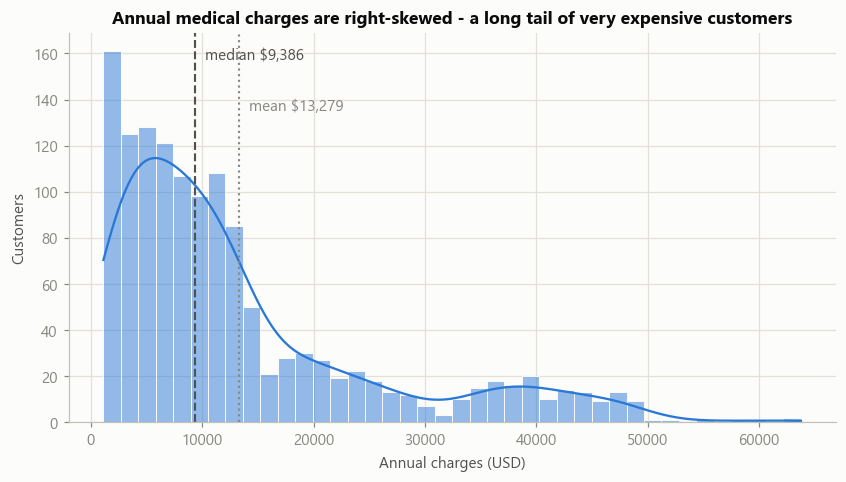

Skewness: 1.52


In [21]:
fig, ax = plt.subplots(figsize=(9, 4.6))
sns.histplot(df["charges"], bins=40, kde=True, color=BLUE, edgecolor=SURFACE, linewidth=0.6, ax=ax)
med, mean = df["charges"].median(), df["charges"].mean()
ax.axvline(med, color=INK2, lw=1.4, ls="--")
ax.axvline(mean, color=MUTED, lw=1.4, ls=":")
ymax = ax.get_ylim()[1]
ax.text(med + 900, ymax * 0.93, rf"median \${med:,.0f}", color=INK2, fontsize=10)
ax.text(mean + 900, ymax * 0.80, rf"mean \${mean:,.0f}", color=MUTED, fontsize=10)
ax.set_title("Annual medical charges are right-skewed - a long tail of very expensive customers")
ax.set_xlabel("Annual charges (USD)")
ax.set_ylabel("Customers")
save_show(fig, "charges_distribution.png")
print(f"Skewness: {df['charges'].skew():.2f}")

Half the book costs under \$9,386 a year, but a long tail runs past \$60,000 (skewness 1.52) — the mean (\$13,279) sits 41% above the median. Flat, table-based pricing is guaranteed to misprice this tail.

### 4.2 Smoking — the single biggest cost driver

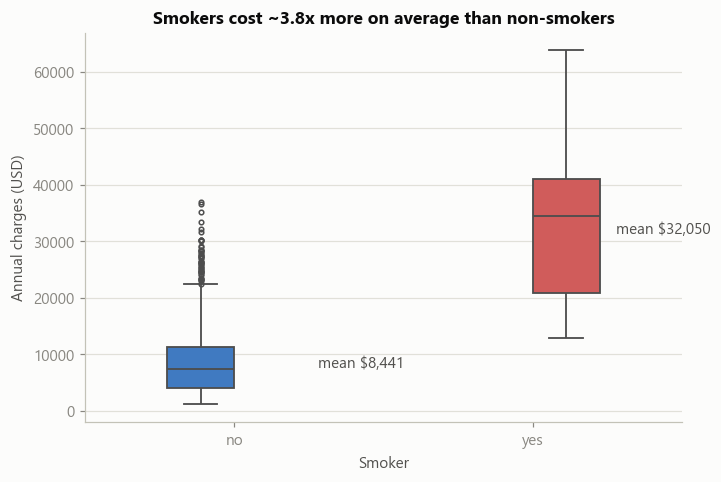

,count,mean,median,std
smoker,,,,
no,1063,8441.0,7346.0,5993.0
yes,274,32050.0,34456.0,11542.0


In [22]:
fig, ax = plt.subplots(figsize=(7, 4.6))
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker", order=["no", "yes"],
            hue_order=["no", "yes"], palette=SMOKER_COLORS, width=0.45,
            legend=False, linewidth=1.2, fliersize=3, ax=ax)
for i, grp in enumerate(["no", "yes"]):
    m = df.loc[df["smoker"] == grp, "charges"].mean()
    ax.text(i + 0.28, m, rf"mean \${m:,.0f}", va="center", fontsize=10, color=INK2)
ax.set_title("Smokers cost ~3.8x more on average than non-smokers")
ax.set_xlabel("Smoker")
ax.set_ylabel("Annual charges (USD)")
save_show(fig, "charges_by_smoker.png")

df.groupby("smoker", observed=True)["charges"].agg(["count", "mean", "median", "std"]).round(0)

Smokers (20% of customers) average **\$32,050** a year against **\$8,441** for non-smokers — a 3.8× gap. The distributions barely overlap: a typical smoker costs more than 75% of non-smokers ever will.

### 4.3 BMI × smoking — an interaction, not a simple slope

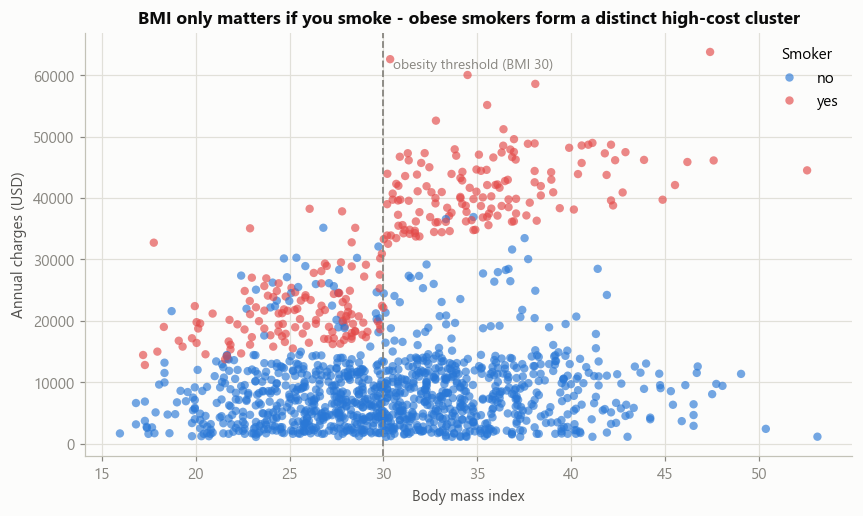

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", hue_order=["no", "yes"],
                palette=SMOKER_COLORS, alpha=0.65, s=30, edgecolor="none", ax=ax)
ax.axvline(30, color=MUTED, lw=1.2, ls="--")
ax.text(30.5, 61000, "obesity threshold (BMI 30)", color=MUTED, fontsize=9)
ax.set_title("BMI only matters if you smoke - obese smokers form a distinct high-cost cluster")
ax.set_xlabel("Body mass index")
ax.set_ylabel("Annual charges (USD)")
ax.legend(title="Smoker", frameon=False)
save_show(fig, "bmi_vs_charges.png")

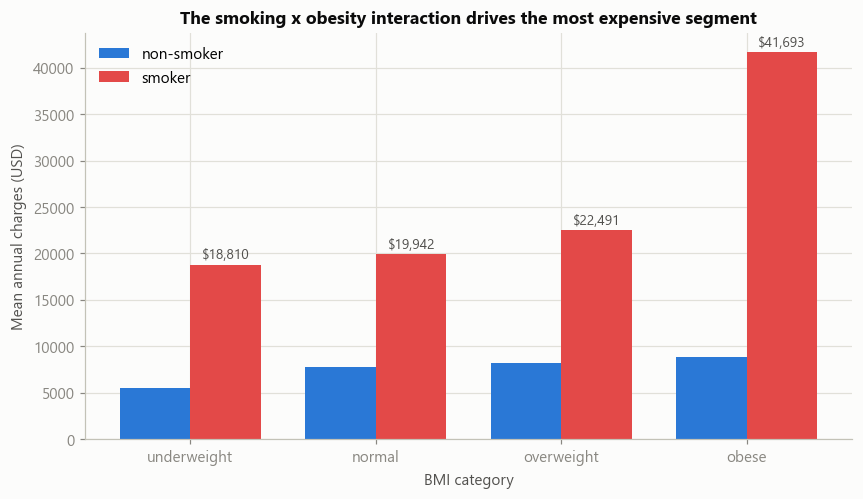

In [24]:
pivot = df.groupby(["bmi_category", "smoker"], observed=True)["charges"].mean().unstack()
x = np.arange(len(pivot.index))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - w / 2, pivot["no"], width=w, color=BLUE, label="non-smoker")
ax.bar(x + w / 2, pivot["yes"], width=w, color=RED, label="smoker")
for xi, v in zip(x + w / 2, pivot["yes"]):
    ax.text(xi, v + 600, rf"\${v:,.0f}", ha="center", fontsize=9, color=INK2)
ax.set_xticks(x, pivot.index.astype(str))
ax.set_title("The smoking x obesity interaction drives the most expensive segment")
ax.set_xlabel("BMI category")
ax.set_ylabel("Mean annual charges (USD)")
ax.legend(frameon=False)
save_show(fig, "bmi_smoker_interaction.png")

**The surprising pattern Ms. Nabil asked about:** for non-smokers, BMI barely moves the bill (\$5,485 → \$8,866 from underweight to obese). For smokers it explodes — obese smokers average **\$41,693**, roughly **4.7× obese non-smokers** and more than double non-obese smokers. Risk is *multiplicative*: BMI is expensive mainly *in combination with* smoking. Any additive pricing table will misprice this segment.

### 4.4 Age — a steady upward trend with visible cost bands

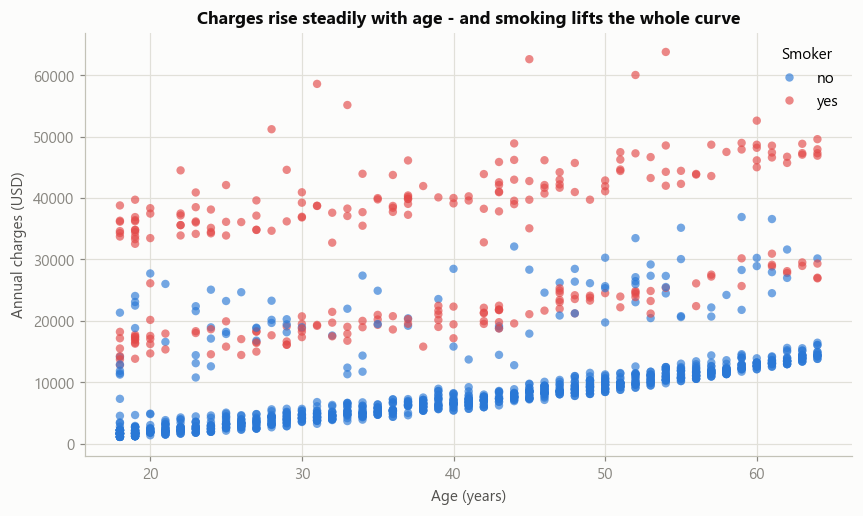

,count,mean,median
age_group,,,
18-29,416,9201.0,3220.0
30-44,392,12491.0,6798.0
45-64,529,17070.0,12029.0


In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", hue_order=["no", "yes"],
                palette=SMOKER_COLORS, alpha=0.65, s=30, edgecolor="none", ax=ax)
ax.set_title("Charges rise steadily with age - and smoking lifts the whole curve")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Annual charges (USD)")
ax.legend(title="Smoker", frameon=False)
save_show(fig, "age_vs_charges.png")

df.groupby("age_group", observed=True)["charges"].agg(["count", "mean", "median"]).round(0)

Costs climb with age in every band (18–29: \$9,201 → 30–44: \$12,491 → 45–64: \$17,070 on average). The scatter shows three parallel "bands": non-smokers (bottom), smokers (top), and a middle band that mixes high-BMI non-smokers with low-BMI smokers — age shifts everyone up at a similar rate (~\$250–280/year, per the regression coefficients later).

### 4.5 What matters less — region, children, sex

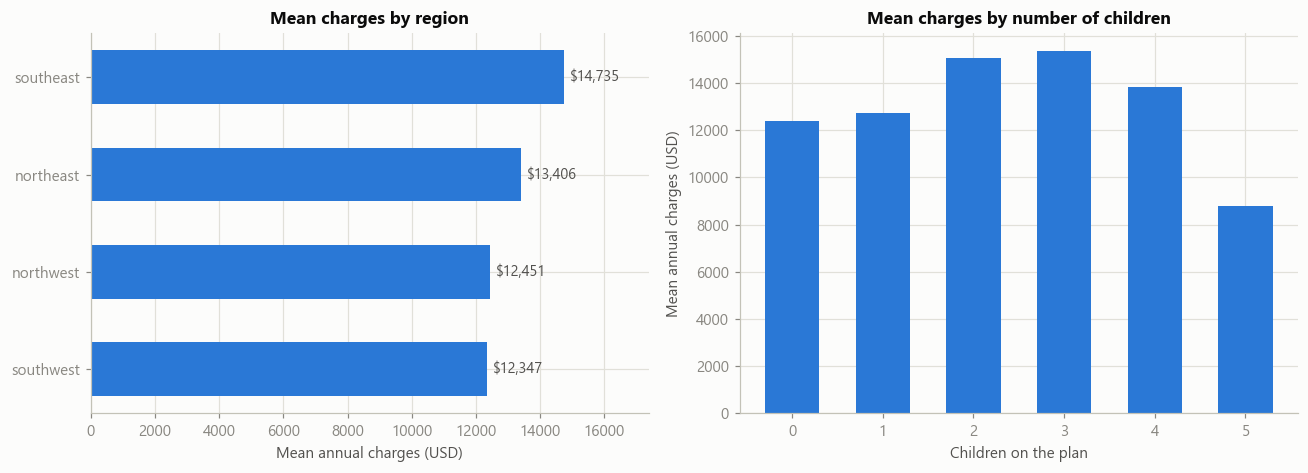

sex
female    12570.0
male      13975.0
Name: charges, dtype: float64


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
region_means = df.groupby("region", observed=True)["charges"].mean().sort_values()
axes[0].barh(region_means.index.astype(str), region_means.values, color=BLUE, height=0.55)
for i, v in enumerate(region_means.values):
    axes[0].text(v + 180, i, rf"\${v:,.0f}", va="center", fontsize=9.5, color=INK2)
axes[0].set_xlim(0, region_means.max() * 1.18)
axes[0].set_title("Mean charges by region")
axes[0].set_xlabel("Mean annual charges (USD)")

child_means = df.groupby("children", observed=True)["charges"].mean()
axes[1].bar(child_means.index.astype(str), child_means.values, color=BLUE, width=0.6)
axes[1].set_title("Mean charges by number of children")
axes[1].set_xlabel("Children on the plan")
axes[1].set_ylabel("Mean annual charges (USD)")
fig.tight_layout()
save_show(fig, "region_children.png")

print(df.groupby("sex", observed=True)["charges"].mean().round(0))

Region spans only \$12,347 (southwest) → \$14,735 (southeast) — and the southeast's edge mostly reflects its higher smoker/BMI mix, not geography itself. Children and sex shift means by even less. These are second-order factors.

### 4.6 Correlation overview

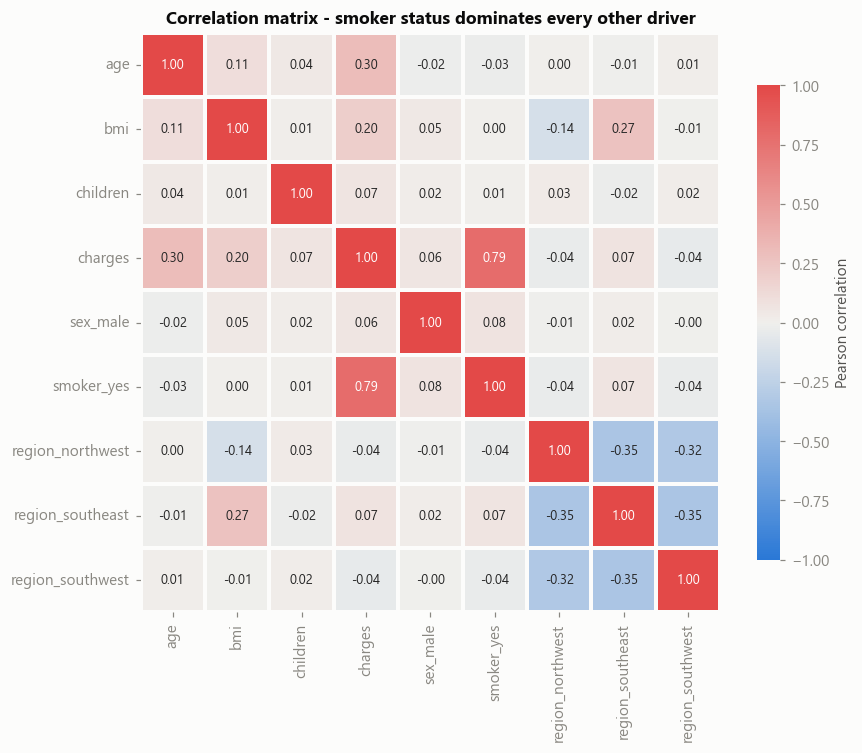

,corr with charges
smoker_yes,0.787
age,0.298
bmi,0.198
region_southeast,0.074
children,0.067
sex_male,0.058
region_southwest,-0.044
region_northwest,-0.039


In [27]:
CORE = ["age", "sex", "bmi", "children", "smoker", "region", "charges"]
corr = pd.get_dummies(df[CORE], columns=["sex", "smoker", "region"],
                      drop_first=True, dtype=int).corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, center=0, vmin=-1, vmax=1,
            square=True, linewidths=1.5, linecolor=SURFACE,
            cbar_kws={"shrink": 0.8, "label": "Pearson correlation"},
            annot_kws={"fontsize": 8.5}, ax=ax)
ax.grid(False)
ax.set_title("Correlation matrix - smoker status dominates every other driver")
save_show(fig, "correlation_heatmap.png")

corr["charges"].drop("charges").sort_values(key=abs, ascending=False).round(3).to_frame("corr with charges")

### 4.7 EDA summary for the stakeholder

**What drives medical costs, in order:**

1. **Smoking** (r = 0.79) — smokers average \$32,050 vs \$8,441; the dominant driver by a wide margin.
2. **Age** (r = 0.30) — a steady ~\$250–280 per extra year for everyone.
3. **BMI** (r = 0.20 overall, but far stronger for smokers) — the **smoking × obesity interaction** is the surprising pattern: obese smokers average \$41,693, ~4.7× obese non-smokers. Risk multiplies, it does not add.
4. **Region, children, sex** — minor (all |r| < 0.08); the southeast looks pricier mainly because it has more smokers with higher BMI.

**Pricing implication:** premiums should be driven primarily by smoking status, age, and BMI-given-smoking. The charges distribution is heavily right-skewed, so models must be judged on how well they price the expensive tail — that is where today's actuarial tables lose money.

## 5. Preprocessing for modeling

- One-hot encode the categoricals (`drop_first=True` to avoid redundant columns): `sex → sex_male`, `smoker → smoker_yes`, `region → 3 dummies`.
- The engineered EDA helpers (`bmi_category`, `age_group`, `obese_smoker`) are **excluded** — they are derived from `age`/`bmi`/`smoker` and would only duplicate information.
- One fixed **80/20 train/test split** (`random_state=42`) shared by every regression model, so the comparison is apples-to-apples. Models that need feature scaling get a `StandardScaler` *inside* a `Pipeline`, so scaling is learned from the training folds only (no test-set leakage, including during cross-validation).

In [28]:
df_model = pd.get_dummies(df[CORE], columns=["sex", "smoker", "region"],
                          drop_first=True, dtype=int)
X = df_model.drop(columns="charges")
y = df_model["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Features: {list(X.columns)}")

Train: 1069 rows | Test: 268 rows
Features: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [29]:
reg_results = []

def evaluate_regression(name, model, X_tr=None, X_te=None):
    # Fit on the training set, report all four required metrics on the held-out test set
    X_tr = X_train if X_tr is None else X_tr
    X_te = X_test if X_te is None else X_te
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    row = {"Model": name,
           "MAE": mean_absolute_error(y_test, pred),
           "MSE": mean_squared_error(y_test, pred),
           "RMSE": root_mean_squared_error(y_test, pred),
           "R2 (test)": r2_score(y_test, pred),
           "R2 (train)": r2_score(y_train, model.predict(X_tr))}
    reg_results.append(row)
    print(f"{name}:  MAE=${row['MAE']:,.0f}  RMSE=${row['RMSE']:,.0f}  "
          f"R2(test)={row['R2 (test)']:.3f}  R2(train)={row['R2 (train)']:.3f}")
    return model

## 6. Regression — *"Predict the medical charges"* (Requirement 2)

Seven model families, all evaluated on the same held-out test set with MAE, MSE, RMSE and R². Hyperparameters are tuned with 5-fold cross-validation **on the training set only**.

### 6.1 Simple Linear Regression — single best predictor

EDA found `smoker` to be the strongest single predictor (r = 0.79, far ahead of age at 0.30), so the one-feature model uses `smoker_yes`.

In [30]:
slr = evaluate_regression("Simple Linear (smoker only)", LinearRegression(),
                          X_train[["smoker_yes"]], X_test[["smoker_yes"]])
print(f"\nBaseline (non-smoker) prediction: ${slr.intercept_:,.0f}")
print(f"Smoker premium (coefficient):     +${slr.coef_[0]:,.0f}")

Simple Linear (smoker only):  MAE=$5,831  RMSE=$7,749  R2(test)=0.673  R2(train)=0.599

Baseline (non-smoker) prediction: $8,498
Smoker premium (coefficient):     +$22,637


A one-question quote — *"do you smoke?"* — already explains ~67% of test-set variance: predict \$8,498 for non-smokers, add \$22,637 for smokers. Powerful, but it prices every smoker identically, so it cannot separate a 20-year-old lean smoker from a 60-year-old obese one.

### 6.2 Multiple Linear Regression — all features

In [31]:
mlr = evaluate_regression("Multiple Linear (all features)", LinearRegression())
pd.Series(mlr.coef_, index=X.columns, name="coefficient (USD)").round(1).to_frame()

Multiple Linear (all features):  MAE=$4,177  RMSE=$5,956  R2(test)=0.807  R2(train)=0.730


,coefficient (USD)
age,248.2
bmi,318.7
children,533.0
sex_male,-101.5
smoker_yes,23077.8
region_northwest,-391.8
region_southeast,-838.9
region_southwest,-659.1


Using all features lifts test R² to 0.81. The coefficients read as a price list: **+\$23,078 if you smoke**, +\$248 per year of age, +\$319 per BMI point, +\$533 per child; sex and region are nearly free. But a straight line cannot express the smoking×BMI interaction EDA found — hence the next model.

### 6.3 Polynomial Regression — degrees 2–4, and the overfitting story

In [32]:
degrees = [1, 2, 3, 4]
poly_train_r2, poly_test_r2 = [], []
for d in degrees:
    pipe = Pipeline([("scale", StandardScaler()),
                     ("poly", PolynomialFeatures(degree=d, include_bias=False)),
                     ("lr", LinearRegression())])
    pipe.fit(X_train, y_train)
    poly_train_r2.append(r2_score(y_train, pipe.predict(X_train)))
    poly_test_r2.append(r2_score(y_test, pipe.predict(X_test)))
    if d >= 2:
        evaluate_regression(f"Polynomial (degree {d})", pipe)

Polynomial (degree 2):  MAE=$2,867  RMSE=$4,646  R2(test)=0.883  R2(train)=0.834
Polynomial (degree 3):  MAE=$3,049  RMSE=$4,870  R2(test)=0.871  R2(train)=0.847


Polynomial (degree 4):  MAE=$3,756  RMSE=$6,058  R2(test)=0.800  R2(train)=0.867


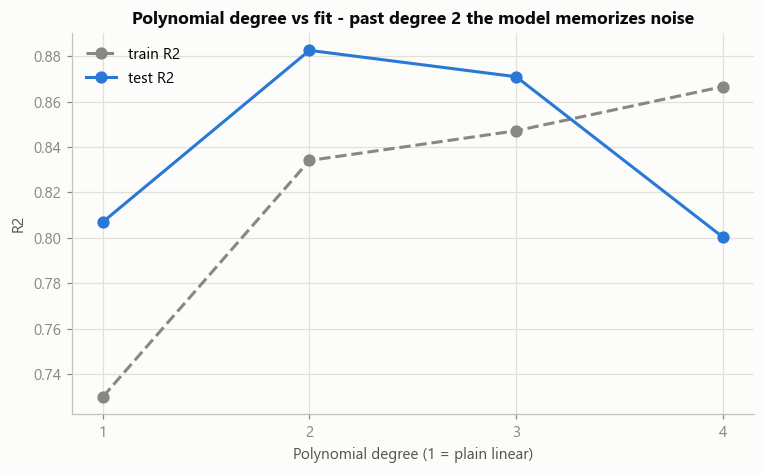

In [33]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(degrees, poly_train_r2, marker="o", ms=7, lw=2, color=MUTED, ls="--", label="train R2")
ax.plot(degrees, poly_test_r2, marker="o", ms=7, lw=2, color=BLUE, label="test R2")
ax.set_xticks(degrees)
ax.set_title("Polynomial degree vs fit - past degree 2 the model memorizes noise")
ax.set_xlabel("Polynomial degree (1 = plain linear)")
ax.set_ylabel("R2")
ax.legend(frameon=False)
save_show(fig, "polynomial_overfitting.png")

**Overfitting, demonstrated.** Degree 2 adds interaction terms (crucially `bmi × smoker_yes`) and jumps test R² from 0.81 → **0.883**. Beyond that, training R² keeps rising (0.834 → 0.847 → 0.867) while test R² *falls* (0.883 → 0.871 → 0.800): the classic signature of a model memorizing training noise instead of learning structure. Degree 2 is the sweet spot.

### 6.4 Ridge Regression (L2) — tuned alpha

In [34]:
ridge_pipe = Pipeline([("scale", StandardScaler()), ("m", Ridge())])
ridge_grid = GridSearchCV(ridge_pipe, {"m__alpha": np.logspace(-3, 3, 25)},
                          cv=5, scoring="neg_root_mean_squared_error")
ridge_grid.fit(X_train, y_train)
alpha_r = ridge_grid.best_params_["m__alpha"]
print(f"Best alpha (5-fold CV): {alpha_r:.3g}")
evaluate_regression(f"Ridge (alpha={alpha_r:.3g})", ridge_grid.best_estimator_)

Best alpha (5-fold CV): 5.62
Ridge (alpha=5.62):  MAE=$4,191  RMSE=$5,973  R2(test)=0.806  R2(train)=0.730


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('m', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",np.float64(5.623413251903491)
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


### 6.5 Lasso Regression (L1) — tuned alpha, eliminated features

In [35]:
lasso_pipe = Pipeline([("scale", StandardScaler()), ("m", Lasso(max_iter=50000))])
lasso_grid = GridSearchCV(lasso_pipe, {"m__alpha": np.logspace(-1, 3, 25)},
                          cv=5, scoring="neg_root_mean_squared_error")
lasso_grid.fit(X_train, y_train)
alpha_l = lasso_grid.best_params_["m__alpha"]
print(f"Best alpha (5-fold CV): {alpha_l:.3g}")
evaluate_regression(f"Lasso (alpha={alpha_l:.3g})", lasso_grid.best_estimator_)

lasso_coefs = pd.Series(lasso_grid.best_estimator_.named_steps["m"].coef_,
                        index=X.columns, name="coefficient (standardized)").round(1)
eliminated = lasso_coefs[lasso_coefs == 0].index.tolist()
print(f"\nFeatures ELIMINATED by Lasso (coefficient shrunk to exactly 0): {eliminated}")
lasso_coefs.sort_values(key=abs, ascending=False).to_frame()

Best alpha (5-fold CV): 46.4
Lasso (alpha=46.4):  MAE=$4,186  RMSE=$5,988  R2(test)=0.805  R2(train)=0.730

Features ELIMINATED by Lasso (coefficient shrunk to exactly 0): ['sex_male']


,coefficient (standardized)
smoker_yes,9182.0
age,3438.5
bmi,1854.7
children,594.2
region_southeast,-199.5
region_southwest,-131.6
region_northwest,-22.7
sex_male,-0.0


With only 8 well-behaved features there is little for regularization to fix, so Ridge (α ≈ 5.6) and Lasso (α ≈ 46) match plain linear regression (R² ≈ 0.81). The interesting output is Lasso's feature selection: it **eliminated `sex_male`** entirely and nearly zeroed the region dummies — independent confirmation of the EDA ranking (smoking ≫ age > BMI > everything else).

### 6.6 Support Vector Regression — two kernels, scaled features *and* target

In [36]:
svr_grids = {
    "linear": {"regressor__svr__C": [0.1, 1, 10]},
    "rbf":    {"regressor__svr__C": [1, 10, 100], "regressor__svr__gamma": ["scale", 0.1]},
}
for kernel, grid in svr_grids.items():
    svr = TransformedTargetRegressor(
        regressor=Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel=kernel))]),
        transformer=StandardScaler())   # SVR needs the TARGET scaled too, not just features
    gs = GridSearchCV(svr, grid, cv=5, scoring="neg_root_mean_squared_error")
    gs.fit(X_train, y_train)
    print(f"SVR ({kernel}) best params: {gs.best_params_}")
    evaluate_regression(f"SVR ({kernel} kernel)", gs.best_estimator_)

SVR (linear) best params: {'regressor__svr__C': 0.1}
SVR (linear kernel):  MAE=$3,431  RMSE=$6,092  R2(test)=0.798  R2(train)=0.702


SVR (rbf) best params: {'regressor__svr__C': 1, 'regressor__svr__gamma': 0.1}
SVR (rbf kernel):  MAE=$2,541  RMSE=$4,692  R2(test)=0.880  R2(train)=0.839


Features **and target** are standardized (via `TransformedTargetRegressor`) — with charges in the tens of thousands, an unscaled SVR barely moves off the mean. The linear kernel matches linear regression (R² 0.80); the RBF kernel captures the interaction and reaches R² **0.880** with the lowest MAE of any model (\$2,541).

### 6.7 Decision Tree Regression — controlled depth

In [37]:
tree_grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                         {"max_depth": range(2, 11), "min_samples_leaf": [1, 5, 10, 20]},
                         cv=5, scoring="neg_root_mean_squared_error")
tree_grid.fit(X_train, y_train)
best_tree = tree_grid.best_estimator_
print(f"Best params: {tree_grid.best_params_} "
      f"(an unconstrained tree overfits badly - depth is the control knob)")
evaluate_regression(f"Decision Tree (depth={tree_grid.best_params_['max_depth']})", best_tree)

Best params: {'max_depth': 4, 'min_samples_leaf': 5} (an unconstrained tree overfits badly - depth is the control knob)
Decision Tree (depth=4):  MAE=$2,621  RMSE=$4,346  R2(test)=0.897  R2(train)=0.855


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

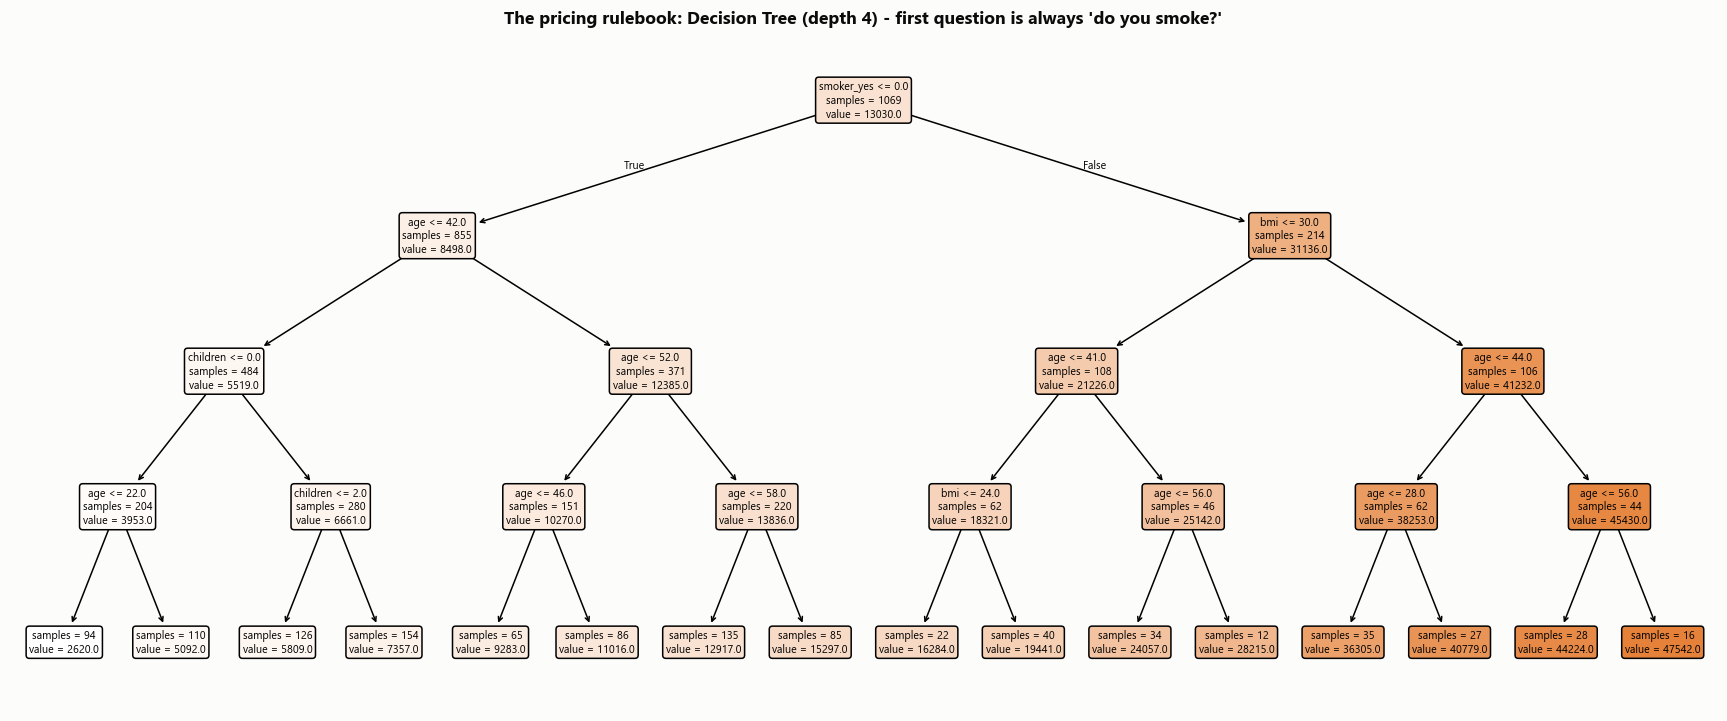

In [38]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(best_tree, feature_names=list(X.columns), filled=True, rounded=True,
          impurity=False, fontsize=7, precision=0, ax=ax)
ax.grid(False)
ax.set_title("The pricing rulebook: Decision Tree (depth 4) - first question is always 'do you smoke?'")
save_show(fig, "decision_tree.png")

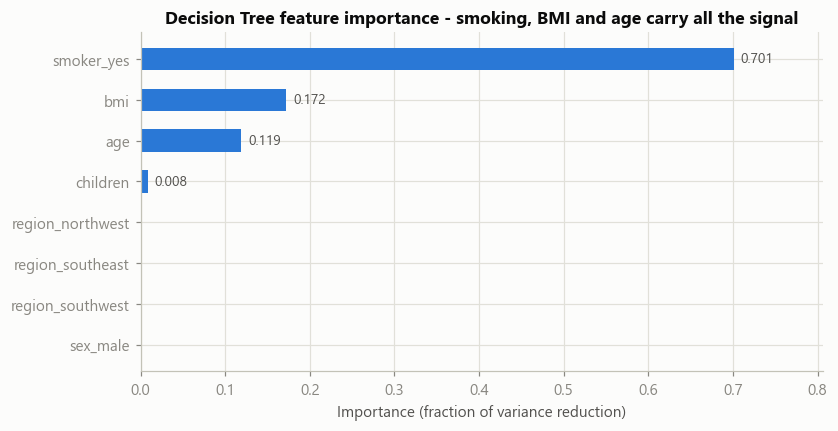

In [39]:
imp = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp.index, imp.values, color=BLUE, height=0.55)
for i, v in enumerate(imp.values):
    if v > 0:
        ax.text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, imp.max() * 1.15)
ax.set_title("Decision Tree feature importance - smoking, BMI and age carry all the signal")
ax.set_xlabel("Importance (fraction of variance reduction)")
save_show(fig, "tree_feature_importance.png")

Cross-validation picks **depth 4 with min 5 samples per leaf** — deep enough to encode *smoke? → BMI over 30? → how old?*, shallow enough not to memorize. The tree reads as an actuarial rulebook, and its importances (smoker 0.70, BMI 0.17, age 0.12, everything else ≈ 0) again match the EDA.

### 6.8 Model comparison & recommendation

In [40]:
reg_summary = pd.DataFrame(reg_results).sort_values("RMSE").reset_index(drop=True)
best_name = reg_summary.loc[0, "Model"]
display_cols = {"MAE": 0, "MSE": 0, "RMSE": 0, "R2 (test)": 3, "R2 (train)": 3}
reg_summary.round(display_cols)

,Model,MAE,MSE,RMSE,R2 (test),R2 (train)
0,Decision Tree (depth=4),2621.0,18886631.0,4346.0,0.897,0.855
1,Polynomial (degree 2),2867.0,21585844.0,4646.0,0.883,0.834
2,SVR (rbf kernel),2541.0,22019125.0,4692.0,0.880,0.839
3,Polynomial (degree 3),3049.0,23719530.0,4870.0,0.871,0.847
4,Multiple Linear (all features),4177.0,35478021.0,5956.0,0.807,0.730
5,Ridge (alpha=5.62),4191.0,35673638.0,5973.0,0.806,0.730
6,Lasso (alpha=46.4),4186.0,35853382.0,5988.0,0.805,0.730
7,Polynomial (degree 4),3756.0,36697661.0,6058.0,0.800,0.867
8,SVR (linear kernel),3431.0,37116675.0,6092.0,0.798,0.702
9,Simple Linear (smoker only),5831.0,60039304.0,7749.0,0.673,0.599


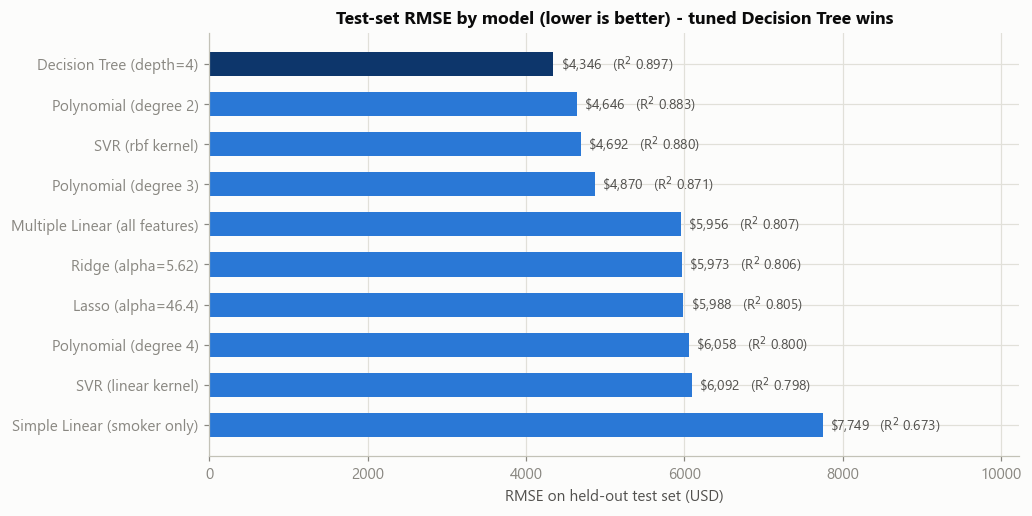

In [41]:
plot_df = reg_summary.sort_values("RMSE", ascending=False)
fig, ax = plt.subplots(figsize=(9.5, 5))
colors = ["#0d366b" if m == best_name else BLUE for m in plot_df["Model"]]
ax.barh(plot_df["Model"], plot_df["RMSE"], color=colors, height=0.6)
for i, (v, r2) in enumerate(zip(plot_df["RMSE"], plot_df["R2 (test)"])):
    ax.text(v + 90, i, rf"\${v:,.0f}   (R$^2$ {r2:.3f})", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, plot_df["RMSE"].max() * 1.32)
ax.set_title("Test-set RMSE by model (lower is better) - tuned Decision Tree wins")
ax.set_xlabel("RMSE on held-out test set (USD)")
save_show(fig, "regression_model_comparison.png")

### Recommendation to the stakeholder: **Decision Tree (depth 4)**

| Rank | Model | MAE | RMSE | R² (test) |
|---|---|---|---|---|
| **1** | **Decision Tree (depth 4)** | **\$2,621** | **\$4,346** | **0.897** |
| 2 | Polynomial (degree 2) | \$2,867 | \$4,646 | 0.883 |
| 3 | SVR (RBF kernel) | \$2,541 | \$4,692 | 0.880 |

**Why the tree:**

1. **Most accurate where it counts.** Best RMSE and R² — and RMSE punishes exactly the large pricing errors (expensive customers priced cheap) that motivated this project. Typical estimates land within ~\$2,600 of actual cost.
2. **It is a pricing rulebook, not a black box.** The tree *is* a flowchart the pricing team (and regulators) can read: smoke? → BMI ≥ 30? → age bracket → quote. SVR's slightly lower MAE does not compensate for being unexplainable in a rate filing.
3. **It natively captures the interaction that matters.** The smoking×obesity effect EDA uncovered is encoded in its first two splits — no manual feature engineering needed.

**Runner-up:** Polynomial (degree 2) — nearly as accurate and produces a smooth premium curve; a good choice if step-free quotes are a business requirement (the tree quotes in ~16 price bands).

## 7. Classification — *"Flag the expensive customers"* (Requirement 3)

**Translation:** finance defines *expensive* as annual charges **above the median**. That is a fixed business threshold (not a parameter learned from features), so it is computed once on the cleaned data: **\$9,386.16**. The target is a balanced binary label; `charges` itself is obviously excluded from the features. Same 80/20 split, now **stratified** to preserve the 50/50 balance; tuning is 5-fold CV on the training set, scored on F1.

In [42]:
median_charges = df["charges"].median()
y_cls = (df["charges"] > median_charges).astype(int)
print(f"'Expensive' threshold (median annual charges): ${median_charges:,.2f}")
print(y_cls.value_counts().rename(index={0: "not expensive (<= median)", 1: "expensive (> median)"}))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls)
print(f"\nTrain: {Xc_train.shape[0]} | Test: {Xc_test.shape[0]} (stratified)")

'Expensive' threshold (median annual charges): $9,386.16
charges
not expensive (<= median)    669
expensive (> median)         668
Name: count, dtype: int64

Train: 1069 | Test: 268 (stratified)


In [43]:
cls_results = []
fitted_classifiers = {}

def evaluate_classifier(name, model, param_grid=None):
    # Tune with 5-fold CV on the training set, then score once on the held-out test set
    if param_grid:
        search = GridSearchCV(model, param_grid, cv=5, scoring="f1")
        search.fit(Xc_train, yc_train)
        print(f"{name} - best params: {search.best_params_}")
        model = search.best_estimator_
    else:
        model.fit(Xc_train, yc_train)
    pred = model.predict(Xc_test)
    proba = model.predict_proba(Xc_test)[:, 1]
    cls_results.append({"Model": name,
                        "Accuracy": accuracy_score(yc_test, pred),
                        "Precision": precision_score(yc_test, pred),
                        "Recall": recall_score(yc_test, pred),
                        "F1": f1_score(yc_test, pred),
                        "ROC-AUC": roc_auc_score(yc_test, proba)})
    r = cls_results[-1]
    print(f"{name}:  accuracy={r['Accuracy']:.3f}  precision={r['Precision']:.3f}  "
          f"recall={r['Recall']:.3f}  F1={r['F1']:.3f}  AUC={r['ROC-AUC']:.3f}\n")
    fitted_classifiers[name] = model
    return model

In [44]:
evaluate_classifier("Logistic Regression",
    Pipeline([("s", StandardScaler()), ("m", LogisticRegression(max_iter=5000))]),
    {"m__C": [0.01, 0.1, 1, 10]})

evaluate_classifier("K-Nearest Neighbors",
    Pipeline([("s", StandardScaler()), ("m", KNeighborsClassifier())]),
    {"m__n_neighbors": range(3, 22, 2)})

evaluate_classifier("SVM (linear)",
    Pipeline([("s", StandardScaler()),
              ("m", SVC(kernel="linear", probability=True, random_state=RANDOM_STATE))]),
    {"m__C": [0.1, 1, 10]})

evaluate_classifier("SVM (RBF)",
    Pipeline([("s", StandardScaler()),
              ("m", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))]),
    {"m__C": [1, 10, 100], "m__gamma": ["scale", 0.1]})

evaluate_classifier("Decision Tree",
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {"max_depth": range(2, 11), "min_samples_leaf": [1, 5, 10]})

evaluate_classifier("Random Forest",
    RandomForestClassifier(random_state=RANDOM_STATE),
    {"n_estimators": [200], "max_depth": [None, 6, 10], "min_samples_leaf": [1, 5]})

evaluate_classifier("Gaussian Naive Bayes", GaussianNB());

Logistic Regression - best params: {'m__C': 1}
Logistic Regression:  accuracy=0.907  precision=0.898  recall=0.918  F1=0.908  AUC=0.953



K-Nearest Neighbors - best params: {'m__n_neighbors': 7}
K-Nearest Neighbors:  accuracy=0.903  precision=0.929  recall=0.873  F1=0.900  AUC=0.938



SVM (linear) - best params: {'m__C': 10}
SVM (linear):  accuracy=0.925  precision=0.932  recall=0.918  F1=0.925  AUC=0.954



SVM (RBF) - best params: {'m__C': 1, 'm__gamma': 0.1}
SVM (RBF):  accuracy=0.929  precision=0.946  recall=0.910  F1=0.928  AUC=0.959



Decision Tree - best params: {'max_depth': 5, 'min_samples_leaf': 10}
Decision Tree:  accuracy=0.937  precision=0.983  recall=0.888  F1=0.933  AUC=0.944



Random Forest - best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest:  accuracy=0.937  precision=0.961  recall=0.910  F1=0.935  AUC=0.944

Gaussian Naive Bayes:  accuracy=0.757  precision=1.000  recall=0.515  F1=0.680  AUC=0.952



In [45]:
cls_summary = (pd.DataFrame(cls_results)
                 .sort_values("F1", ascending=False).reset_index(drop=True))
cls_summary.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.937,0.961,0.910,0.935,0.944
1,Decision Tree,0.937,0.983,0.888,0.933,0.944
2,SVM (RBF),0.929,0.946,0.910,0.928,0.959
3,SVM (linear),0.925,0.932,0.918,0.925,0.954
4,Logistic Regression,0.907,0.898,0.918,0.908,0.953
5,K-Nearest Neighbors,0.903,0.929,0.873,0.900,0.938
6,Gaussian Naive Bayes,0.757,1.000,0.515,0.680,0.952


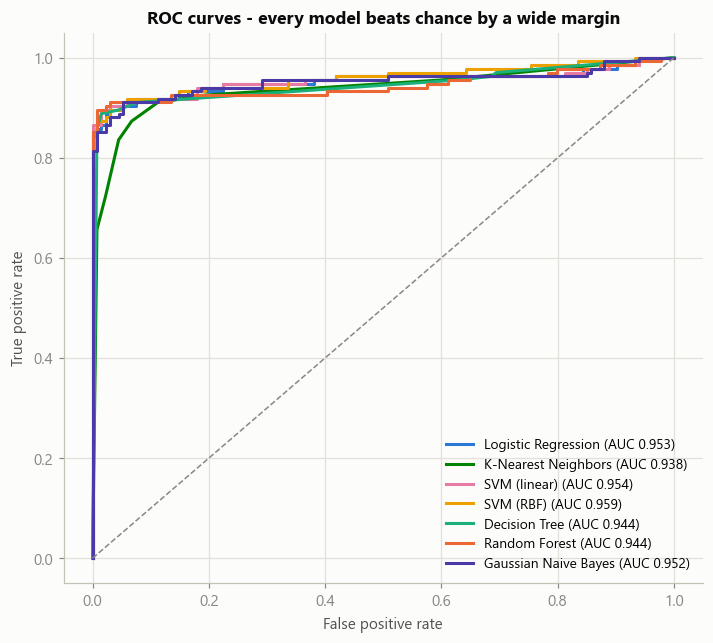

In [46]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for (name, model), color in zip(fitted_classifiers.items(), CATEGORICAL):
    proba = model.predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, proba)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC {roc_auc_score(yc_test, proba):.3f})")
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax.set_title("ROC curves - every model beats chance by a wide margin")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(frameon=False, fontsize=9, loc="lower right")
save_show(fig, "classification_roc.png")

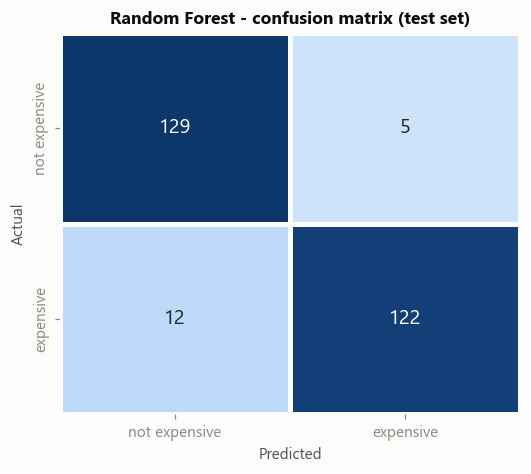

Of 134 truly expensive customers, 122 were flagged (91.0% recall);
12 slipped through as false negatives - the costly error type for HealthGuard.


In [47]:
best_cls_name = "Random Forest"
best_cls = fitted_classifiers[best_cls_name]
cm = confusion_matrix(yc_test, best_cls.predict(Xc_test))

fig, ax = plt.subplots(figsize=(5.4, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap=SEQ_BLUES, cbar=False,
            linewidths=2, linecolor=SURFACE,
            xticklabels=["not expensive", "expensive"],
            yticklabels=["not expensive", "expensive"],
            annot_kws={"fontsize": 13}, ax=ax)
ax.grid(False)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"{best_cls_name} - confusion matrix (test set)")
save_show(fig, "confusion_matrix.png")

tn, fp, fn, tp = cm.ravel()
print(f"Of {tp + fn} truly expensive customers, {tp} were flagged ({tp / (tp + fn):.1%} recall);")
print(f"{fn} slipped through as false negatives - the costly error type for HealthGuard.")

### Classification recommendation: **Random Forest**

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| **Random Forest** | **0.937** | 0.961 | **0.910** | **0.935** | 0.944 |
| Decision Tree | 0.937 | 0.983 | 0.888 | 0.933 | 0.944 |
| SVM (RBF) | 0.929 | 0.946 | 0.910 | 0.928 | **0.959** |

- **Random Forest** takes the recommendation: the best F1 (0.935) with the strongest balance of precision (0.961) and recall (0.910).
- For HealthGuard the expensive error is the **false negative** — an expensive customer priced as cheap is a direct loss, while a false positive merely risks a slightly high quote. That asymmetry favors the Forest over the single Decision Tree (recall 0.910 vs 0.888) despite identical accuracy.
- If leadership wants to trade a little precision for even higher recall, the Forest's probability threshold can simply be lowered below 0.5 — no retraining needed.
- Gaussian Naive Bayes is the cautionary tale: perfect precision but it misses **half** of the expensive customers (recall 0.515) — exactly the failure mode the company already suffers from.

## 8. Final recommendation to Ms. Nabil

**What drives cost.** Three factors, in order: smoking (smokers cost 3.8× more, \$32,050 vs \$8,441), age (~\$250–280 per year), and BMI — whose effect *multiplies* with smoking (obese smokers average \$41,693, ~4.7× obese non-smokers). Sex, region and children barely matter; Lasso regression independently discarded sex entirely.

**Pricing tool (Requirement 2).** Deploy the **depth-4 Decision Tree**: R² = 0.897, typical error ≈ \$2,600, and it doubles as a human-readable pricing rulebook that survives regulatory scrutiny. Keep Polynomial-2 as the alternative if smooth (non-banded) quotes are required.

**Expensive-customer flag (Requirement 3).** Deploy the **Random Forest**: 93.7% accuracy, and it catches 91% of the expensive customers today's tables misprice. Lower its decision threshold if the finance team wants an even wider net.

**Honest limitations.**
- 1,337 customers is modest; retrain as HealthGuard's own book grows, and validate on it before going live.
- The data has no claims history, chronic conditions, or medications — the strongest actuarial signals are still on the table.
- Self-reported smoking status is under-reported in practice; consider verification for large policies.
- Using `sex` (or proxies) in pricing may be restricted in some jurisdictions — conveniently, the models barely use it, so dropping it costs almost nothing.
- Charges are a single-year snapshot; a longitudinal view would let us price multi-year risk.

---

### Appendix — where each pandas wrangling technique appears

| Technique | Where |
|---|---|
| Reading with encoding / profiling (`head`, `shape`, `info`, `describe`, `value_counts`) | §2 |
| Missing-value handling | §3.1 |
| Dropping duplicates | §3.2 |
| Replacing / standardizing values (`str.strip`, `str.lower`, `map`) | §3.3, §3.6 |
| Validity filtering (`between`, boolean masks) | §3.4 |
| Type conversion (`astype("category")`) | §3.5 |
| Creating columns (`pd.cut`, boolean logic, `map`) | §3.6 |
| Selecting (`[]`, `loc`), filtering, sorting (`sort_values`) | §3.7 |
| Grouping + aggregating (`groupby`, `agg`, `mean`, `unstack`) | §3.7, §4 |
| Merging (`merge`) and concatenating (`concat`) | §3.7 |
| Renaming (`rename`) | §3.7 |
| Dropping columns (`drop`) / encoding (`get_dummies`) | §5 |
| Applying functions across data (evaluation helpers over models) | §5–7 |
| Resampling | *Not applicable* — resampling requires a datetime axis, and this dataset has no time dimension (one snapshot per customer). Noted rather than forced. |